# Introduction to Time Series

Any metric that is measured over regular time intervals makes a Time Series.

Some examples include:
* Maximum temperature of day in London
* Google daily closing stock prices
* Hourly energy consumption in Paris

**Definition**: **Time series** is a dataset of observations indexed in time order
$$ \{x_t \} = \{x_t | t \in \{1, 2, ..., n\} \} = (x_1, x_2, ..., x_n)$$

where $x_t$ is an observation at the time step $t$.

**Example**: $(1.2, -0.3, 2.0, 0.3, -0.2)$ is a time series of $N = 5$ observations. We have:

$$
x_1 = 1.2 \\
x_2 = -0.3 \\
x_3 = 2.0 \\
x_4 = 0.3 \\
x_5 =-0.2
$$

## Stochastic Process

**Definition**: A **stochastic process** is a collection of random variables $\{X_t\}$ indexed over time. Each random variable is defined via **joint distributions**

$$
P\{X_1 \le x_1, X_2 \le x_2, ... X_n \le x_n\}, \\
x_1, x_2, ..., x_n \in \mathbf{R} \\
n \in \mathbf{N}
$$

**Time series** is a single realization of the underlying stochastic process. It is the sequence of observed data points $\{x_t\}_{t=1}^n$ where $x_t = X_t(\omega)$ for a specific outcome $\omega$.

**Example**: Let $\{X_t\}_{t \in \mathbf{N}}$ be a sequence of independent and identically distributed (i.i.d.) random variables such that:
$$
X_t \sim \mathcal{N}(0, 1^2)
$$

$\{X_t\}_{t \in \mathbf{N}}$ is stochastic process.

Because random variables are normally distributed we have:
$$
P\{X_t \le x_t \} = \int_{-∞}^{x_t} \frac{1}{\sqrt{2 \pi \sigma^2}} e^{\frac{1}{(x_t-\mu)^2}} = \int_{-∞}^{x_t} \frac{1}{\sqrt{2 \pi}} e^{\frac{1}{x_t^2}} = \phi(x_t), \, \forall t
$$

**Joint distributions** of process $\{X_t\}$ are:

$$
P\{X_1 \le x_1, ..., X_n \le x_n \} \\
\overset{\text{independence}}{=} P\{X_1 \le x_1\} \cdot ... \cdot P\{X_n \le x_n\} \\
= \phi(x_1)\cdot ... \cdot \phi(x_n), \, \forall t
$$


Any realization of stochastics process $\{X_t\}$ above is time series.

Let's generate two realizations of mentioned process using `numpy`. Each of them will have size $n=10$.

In [ ]:
import numpy as np

In [ ]:
# Generate time series data by sampling from the Gaussian distribution
time_series_1 = np.random.normal(0, 1, 10)
time_series_1

array([-1.11588576,  0.7578002 ,  1.81577995, -0.29940221, -0.27981055,
       -0.78124967, -4.11181773, -1.26713608, -0.120414  , -0.84778434])

In [ ]:
time_series_2 = np.random.normal(0, 1, 10)
time_series_2

array([-0.8411935 ,  0.4203351 , -0.49532636,  1.11582811,  0.36544814,
       -0.60524745,  0.23667298, -1.06851439, -1.62406912, -0.58030197])

Now, let's plot both time series using `mathplotlib`.

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

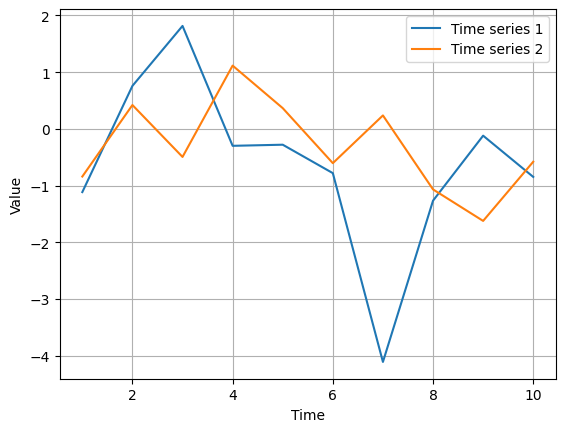

In [ ]:
time = np.arange(10) + 1

# Plot the time series
plt.figure()
plt.plot(time, time_series_1, label='Time series 1')
plt.plot(time, time_series_2, label='Time series 2')

plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.show()

**Example**: Let $\{Z_t\}_{t \in \mathbf{N}}$ be a sequence of independent and identically distributed (i.i.d.) random variables such that:
$$
P\{Z_t=1\} = p \\
P\{Z_t=-1\} = 1 - p
$$

The **simple random walk** $\{S_t\}_{t \in \mathbf{N_0}}$ is stochastic process defines by the partial sums:

$$
S_0 = 0 \\
S_t = Z_1 + Z_2 + ... + Z_t = \sum_{i=1}^t Z_i
$$

$S_t$ represents the position of the "walker" at time $t$.



Since a time series is single realization of the stochastic process, let's generate $5$ time series by sampling.

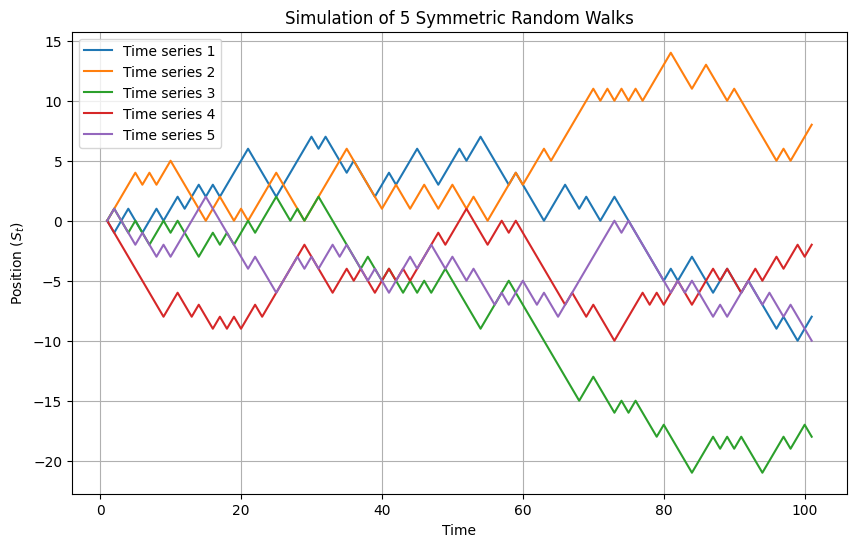

In [ ]:
z = np.random.choice([-1, 1], size=(5, 100))

# Calculate the cumulative sum to get the walk positions
# We prepend a column of zeros for the starting position S_0 = 0
s = np.concatenate([np.zeros((5, 1)), np.cumsum(z, axis=1)], axis=1)

t = np.arange(101) + 1

# Plotting
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(t, s[i], label=f'Time series {i+1}')

plt.title(f"Simulation of 5 Symmetric Random Walks")
plt.xlabel("Time")
plt.ylabel("Position ($S_t$)")
plt.legend()
plt.grid(True)

plt.show()

## Relationship between Time Series and Stochastic Process

In the study of stochastic processes, the relationship between a **Stochastic Process** and a **Time Series** is analogous to the relationship between a **Random Variable** and a **Number**.

* In practice, we only have a time series $\{x_t\}$, not a specification of the joint distributions of a sequence of random variables $\{X_t\}$.
* For a given time series $\{x_t\}$ we don't know the true underlying stochastic process of which $\{x_t\}$ is a realization.
* Because of that, we test the data to see if it has certain properties (like a trend or seasonality) and select a **time series model** that best mimics that process.
* For example, for a given time series dataset $\{x_t\}$ we might fit an AR(1) model with a coefficient of $1.0$: $$X_t = 1.0 \cdot X_{t-1} + \epsilon_t$$

Term **time series** used in different contexts can mean one of the following three things:
1. the **dataset** $\{x_t\}$
2. the **underlying stochastic process** of which it is a realization
3. the **time series model** that we use to aproximate the underlying stochastic proccess.

## `statsmodels` Toy Datasets

Python's package `statsmodels` provides toy time series datasets for use in examples, tutorials and model testing.

Here’s how to list out all of the avalible datasets:

In [ ]:
import statsmodels.api as sm

In [ ]:
print('Name               Title')
print('----               -----')
for attribute in dir(sm.datasets):
    # If the attribute is a module
    if str(type(getattr(sm.datasets, attribute))) == "<class 'module'>":
        # The utils module is not a dataset
        if attribute == 'utils':
            continue
        title = getattr(sm.datasets, attribute).TITLE
        print(f'{attribute:18s} {title}')

Name               Title
----               -----
anes96             American National Election Survey 1996
cancer             Breast Cancer Data
ccard              Bill Greene's credit scoring data.
china_smoking      Smoking and lung cancer in eight cities in China.
co2                Mauna Loa Weekly Atmospheric CO2 Data
committee          First 100 days of the US House of Representatives 1995
copper             World Copper Market 1951-1975 Dataset
cpunish            US Capital Punishment dataset.
danish_data        Danish Money Demand Data
elnino             El Nino - Sea Surface Temperatures
engel              Engel (1857) food expenditure data
fair               Affairs dataset
fertility          World Bank Fertility Data
grunfeld           Grunfeld (1950) Investment Data
heart              Transplant Survival Data
interest_inflation (West) German interest and inflation rate 1972-1998
longley            Longley dataset
macrodata          United States Macroeconomic data
modechoi

### **Example** [Mauna Loa Weekly Atmospheric CO2 Data](https://www.statsmodels.org/stable/datasets/generated/co2.html)

The data returned by `load_pandas` contains the dates as the index.

In [ ]:
# Load the data
co2 = sm.datasets.co2.load_pandas()

The `dataset` object follows the bunch pattern. The full dataset is available in the `data` attribute structured as `pandas` `DataFrame`.

In [ ]:
# Print first 10 samples of the co2 time series dataset
co2.data.head(10)

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4
1958-05-03,316.9
1958-05-10,NaN
1958-05-17,317.5
1958-05-24,317.9
1958-05-31,NaN


For the CO2 dataset measures are weekly. For convenience we choose index set to be $\mathbf{N_0}$ and write:

$$
x_0 = 316.1 \\
x_1 = 317.3 \\
x_2 = 317.6 \\
...
$$

To visualize the time series we use `matplotlib` package.

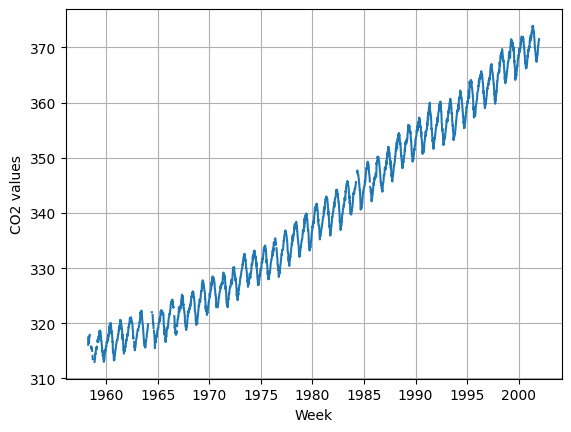

In [ ]:
# Plot the time series
plt.figure()
plt.plot(co2.data)

plt.xlabel('Week')
plt.ylabel('CO2 values')
plt.grid(True)

plt.show()

## Goal of time series analysis

The **goal of time series analysis** is to:
* Find the appropriate time series model that fits the given time series dataset
* Forecast the future values of a time series from current and past values.

**Resources**:

*   Brockwell, P. J., & Davis, R. A. (2016). *Introduction to Time Series and Forecasting* (3rd ed.). Springer (pp. 6-18)

* Nicholls, Rowan. [“Example Datasets: Statsmodels”](https://rowannicholls.github.io/python/data/statsmodels_datasets.html) *GitHub Pages*, Accessed 20 Jan. 2026.
